In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("solar_system.csv")

In [3]:
df.shape

(20, 11)

In [4]:
print(df.shape[0], "rows")
print(df.shape[1], "columns")

20 rows
11 columns


In [5]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [6]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [7]:
df.columns

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')

In [8]:
df.index

RangeIndex(start=0, stop=20, step=1)

In [9]:
print(df.index)

RangeIndex(start=0, stop=20, step=1)


In [10]:
print(df.head())
print(df.columns)

                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [11]:
print(df["Attribute"])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [12]:
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)

In [13]:
semi_major_axis = (perihelion + aphelion) / 2

In [14]:
semi_major_row = pd.Series(semi_major_axis, name="Semi-Major Axis (AU)")
df = pd.concat([df, semi_major_row.to_frame().T])

In [15]:
df.shape

(21, 11)

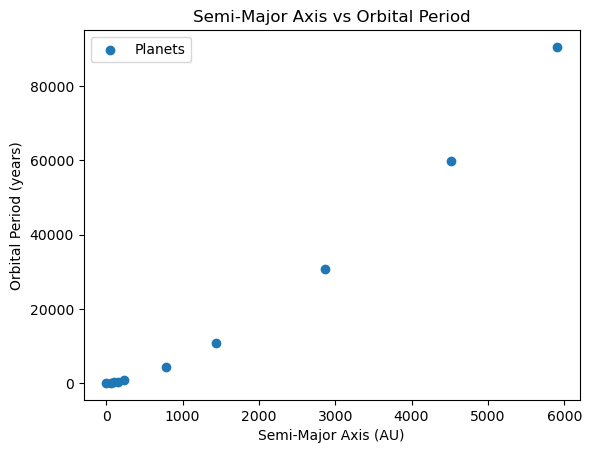

In [16]:
plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title("Semi-Major Axis vs Orbital Period")
plt.legend()
plt.show()

In [17]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [18]:
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)

In [19]:
m_fit = popt[0]

In [20]:
print(f"Fit: T = {m_fit:.2f} * a^1.5")

Fit: T = 0.20 * a^1.5


In [21]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof

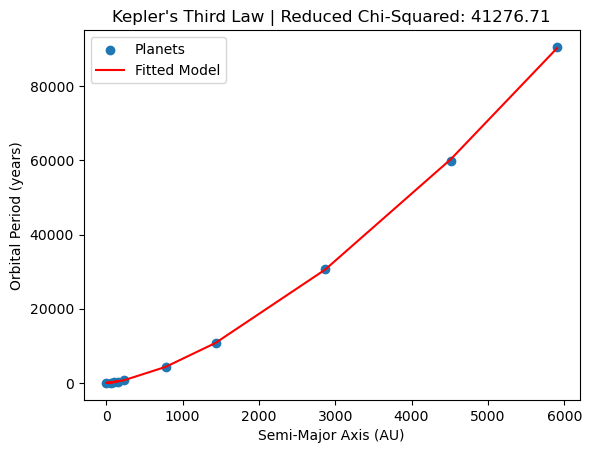

In [22]:
plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, m_fit), color="red", label="Fitted Model")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title(f"Kepler's Third Law | Reduced Chi-Squared: {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [23]:
df.to_csv("kepler.csv")